In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_agent_lstm as d3qn_per_agent
import configurations.config_p3_sub2 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p3_sub2' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub2.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_agent_lstm import D3QN_PER
from configurations.config_p3_sub2 import config

In [5]:
import sequenceReplayBuffer
print(sequenceReplayBuffer.__file__)
import inspect
print(inspect.getsource(sequenceReplayBuffer.SeqReplayBuffer.sample))

c:\Users\hgoel\MTech_Resources\DRL\Capstone_Project\CS780-OBELIX\run_scripts\..\sequenceReplayBuffer.py
    def sample(self, **kwargs):
        priorities = np.array(self.prioritiesOverEpisodes, dtype=np.float32)

        # clean priorities
        priorities = np.nan_to_num(priorities, nan=1e-6, posinf=1.0, neginf=1e-6)
        priorities = np.abs(priorities) + 1e-6

        probs = priorities ** self.alpha

        # clean probs
        probs = np.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)

        prob_sum = probs.sum()

        if prob_sum <= 0 or not np.isfinite(prob_sum):
            probs = np.ones(len(probs)) / len(probs)
        else:
            probs = probs / prob_sum

        batch_experiences = []
        batch_weights = []
        start_indices = []

        N = self.length()
        batch = min(self.batchSize, N)

        indices = np.random.choice(N, batch, replace=True, p=probs)

        updatedBeta = min(1.0, self.beta + self.beta_rate * kwargs['running_step'

In [6]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0003, 'MAX_TRAIN_EPISODES': 200, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 150, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x000002400212BF60>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x000002400212BEC0>, 'max_steps': 1000, 'epochs': 20, 'epsilon': 0.58, 'eps_decay_strategy': [('exponential', {'s': 0, 'e': 249, 'ival': 1.0, 'fval': 0.005})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.005, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [512, 512, 256], 'lstm_hDim': 256, 'model_path': '../model_weights_phase3_sub2', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 15, 'minSamples': 2}


In [7]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)
d3qnPerwithLSTMAgent = D3QN_PER(env, config)

In [8]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerwithLSTMAgent.runD3QN_PER()

Episode 0: TR -11933.0 | ER -161589.2 | TT 3.5670042037963867 | WC 33.804845333099365 | TS 263
Episode 1: TR -34682.0 | ER -175045.2 | TT 41.777753591537476 | WC 77.29923892021179 | TS 1000
Episode 2: TR -24970.0 | ER -918.8 | TT 88.4549629688263 | WC 124.94181752204895 | TS 1000
Episode 3: TR -4085.0 | ER -4740.6 | TT 136.09497165679932 | WC 174.00672960281372 | TS 1000
Episode 4: TR -38570.0 | ER -403.8 | TT 185.12729167938232 | WC 217.41520285606384 | TS 1000
Episode 5: TR -67967.0 | ER -333.8 | TT 228.4795274734497 | WC 261.06723260879517 | TS 1000
Episode 6: TR -19068.0 | ER -919.4 | TT 272.6047637462616 | WC 310.15710401535034 | TS 1000
Episode 7: TR -974.0 | ER -48142.4 | TT 321.6190412044525 | WC 354.7925477027893 | TS 1000
Episode 8: TR -13472.0 | ER -384.8 | TT 366.0276882648468 | WC 396.72377157211304 | TS 1000
Episode 9: TR 2061.0 | ER -890.0 | TT 397.520859003067 | WC 434.4092128276825 | TS 68
Episode 10: TR -17474.0 | ER -121675.8 | TT 445.749285697937 | WC 475.9595558643

In [9]:
import numpy as np
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -40328.0


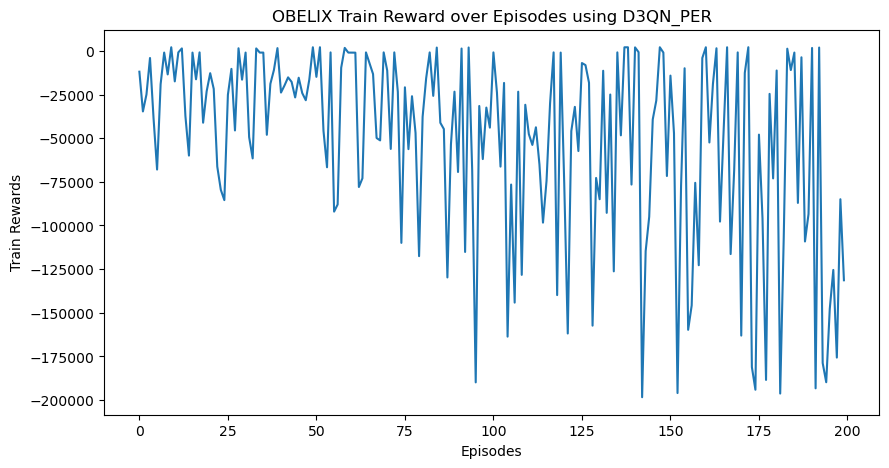

In [10]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

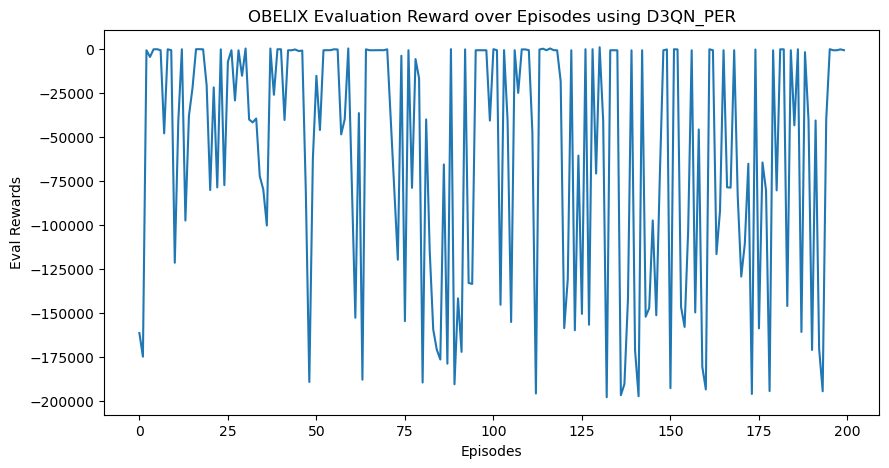

In [11]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

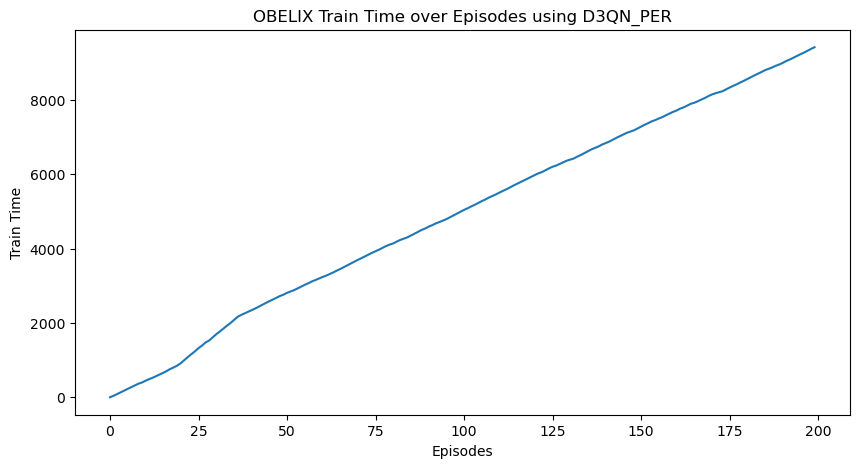

In [12]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

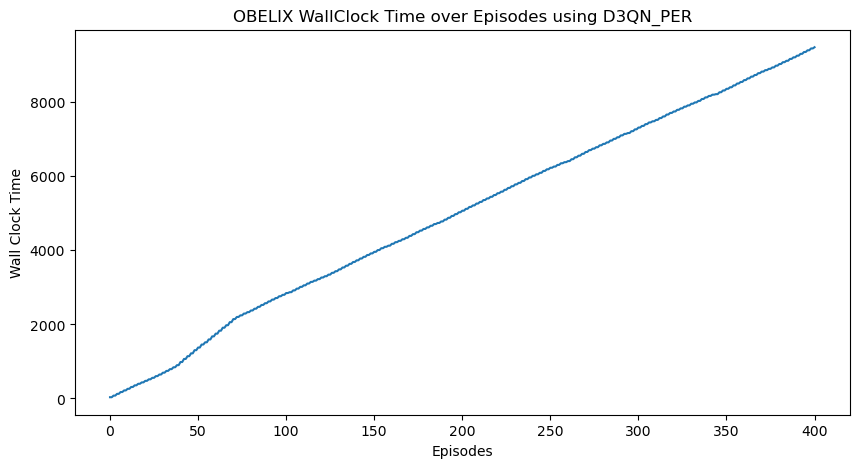

In [13]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

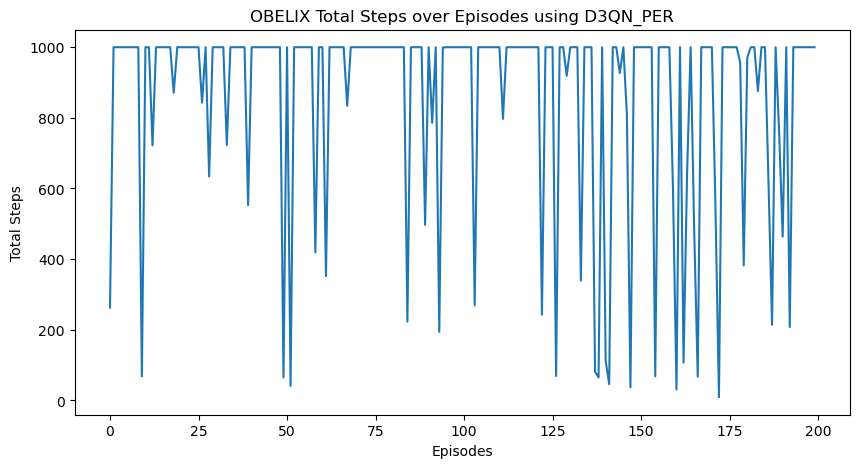

In [14]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)